# Data Collection & Indicator calucation

In [368]:
from sklearn.exceptions import DataConversionWarning
import warnings

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)

In [369]:
import pandas as pd
import numpy as np

data = pd.read_csv("/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /Data Set/vcb_Training_Data.csv")
"""
data = data.set_index("Date")
"""
data.rename(columns={'Unnamed: 0': 'time'}, inplace=True)
data.set_index("time", inplace=True)

df = data.copy()

training_data = df.loc[:, ~df.columns.isin(["target", "strength target", "regression target"])].copy()
target= df.loc[:, ["target"]].copy()

display(training_data.shape, target.shape)
display(data)

(3214, 108)

(3214, 1)

,open,high,low,close,volume,vnindex,vn30,hnx,gold,oil,...,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr,target
time,,,,,,,,,,,,,,,,,,,,,
2012-04-23,7.82,7.91,7.79,7.82,404510.0,465.17,533.60,77.81,1631.900024,118.709999,...,3.463147,1.301056,18.878575,16.927344,1.951231,6.833936,0.704225,0.701757,41.261261,0.0
2012-04-24,7.84,7.84,7.70,7.77,643880.0,465.65,534.89,78.57,1643.000000,118.160004,...,3.791061,1.311654,16.605561,16.862987,-0.257426,6.836437,-1.398601,-1.408474,40.900901,0.0
2012-04-25,7.89,7.89,7.72,7.77,560280.0,472.87,542.78,79.55,1641.400024,119.120003,...,4.173091,1.528121,22.493083,17.989006,4.504076,6.837802,-0.283688,-0.284091,40.000000,0.0
2012-04-26,7.84,7.84,7.74,7.74,507420.0,470.21,538.10,78.74,1659.599976,119.919998,...,4.470873,1.191129,22.381355,18.867476,3.513879,6.945705,-3.413940,-3.473576,40.000000,0.0
2012-04-27,7.86,7.96,7.77,7.86,587740.0,473.77,541.20,79.86,1664.000000,119.830002,...,4.688938,0.872261,20.622134,19.218408,1.403726,7.046370,1.767305,1.751870,39.459459,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-28,69.50,70.60,68.70,69.00,8799400.0,1680.86,1861.20,276.63,3431.800049,68.620003,...,0.605956,0.882843,27.378349,15.621999,11.756349,62.478224,-1.149425,-1.156082,1145.045045,0.0
2025-08-29,69.20,70.10,68.50,68.60,14696100.0,1682.21,1865.38,279.98,3473.699951,68.120003,...,0.864885,1.035717,29.479506,18.393501,11.086005,62.726694,0.000000,0.000000,1143.243243,0.0
2025-09-03,68.80,68.80,67.00,67.00,14216900.0,1681.30,1859.59,282.70,3593.199951,67.599998,...,1.123181,1.033182,24.856416,19.686084,5.170332,62.933113,1.495017,1.483951,1136.036036,1.0


## Data Preparation:

In [370]:
def data_split(split_percentage, df):

    assert 0 < split_percentage < 1, "split_percentage must be a float between 0 and 1 (exclusive)"
    
    split_index = int(len(df) * split_percentage)

    train_df = df.iloc[:split_index].copy()
    test_df = df.iloc[split_index:].copy()
    
    return train_df, test_df

In [371]:
from sklearn.model_selection import train_test_split

def define_rule_based_indicators_list(X):
    rule_based_indicators =[]
    for col in X.columns:
        if len(X[col].unique()) <= 2:
            rule_based_indicators.append(col)
    
    return rule_based_indicators

print(define_rule_based_indicators_list(training_data))

#X, Valid_set, y, Valid_result = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
X, Valid_set = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
y, Valid_result = target.reset_index(drop=True).loc[X.index], target.reset_index(drop=True).loc[Valid_set.index]

['hour', 'minute', 'minute_segment', 'monday_morning', 'friday_afternoon', 'pre_holiday_afternoon', 'post_holiday_morning', 'volatility_bbhi', 'volatility_bbli', 'volatility_kchi', 'volatility_kcli', 'trend_psar_up_indicator', 'trend_psar_down_indicator']


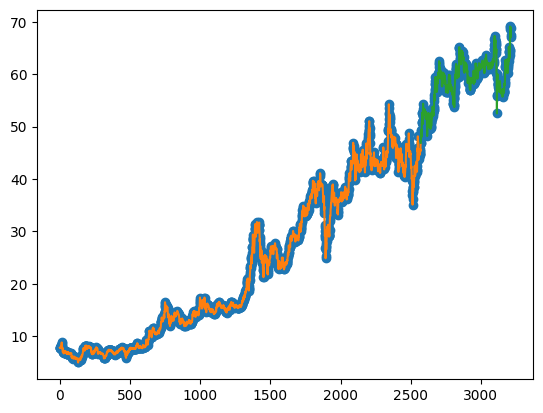

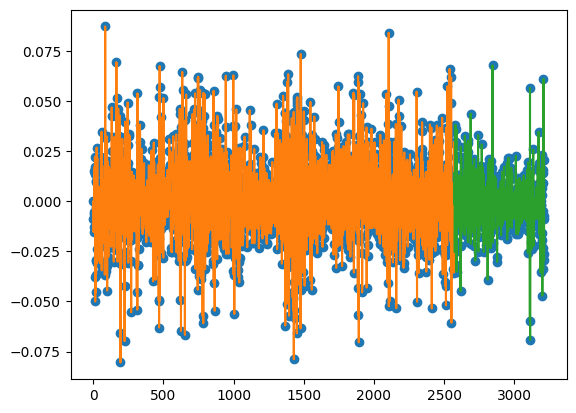

In [372]:
import matplotlib.pyplot as plt

df = training_data.reset_index(drop=True)
price = df.loc[:, 'close']
plt.plot(price.index, price.values, 'o')

for df in [X, Valid_set]:
    price = df.loc[:, 'close']
    plt.plot(price.index, price.values)
plt.show()


df = training_data.reset_index(drop=True)
price = df.loc[:, 'log_return']
plt.plot(price, 'o')

for df in [X, Valid_set]:
    price = df.loc[:, 'log_return']
    plt.plot(price.index, price.values)
plt.show()

## Scoring for Tuning and Optimization:

In [ ]:
'''
scoring = "roc_auc"
scoring = "accuracy"
'''
scoring = "f1"

### GMM model import:

In [374]:
import joblib
from sklearn.mixture import GaussianMixture

package = joblib.load(f"/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/gmm_model_with_threshold.pkl")

gmm_model = package["model"]
gmm_array = package["array"]

gmm_model, gmm_array

(GaussianMixture(n_components=4, random_state=42), 'log_return')

### MSM model import:

In [375]:
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import joblib

package = joblib.load(f"/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/msm_model_with_threshold.pkl")

msm_model = MarkovRegression(**package)

### Fold CV fucntion:

In [376]:
def purged_kfold_split(X, n_splits=5, lookahead=5, embargo=0):
    fold_size = len(X) // n_splits
    for i in range(n_splits):
        test_start = i * fold_size
        test_end = (i + 1) * fold_size

        # Embargo
        embargo_start = test_end + 1
        embargo_end = embargo_start + embargo

        # Purge overlaps
        train_idx = list(range(0, test_start - lookahead)) + list(range(embargo_end, len(X)))
        test_idx = list(range(test_start, test_end))

        yield train_idx, test_idx

### SMOTE model setting:

In [377]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy='auto',  # or float/dict/‘auto’
    random_state=42,
    k_neighbors=2,                     # neighbors used to generate synthetic samples
)

### Model Evaluation:

In [402]:

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, classification_report, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.utils.class_weight import compute_sample_weight

def Evaluation_for_Testing_part(model, X=X.copy(), y=y.copy(), Valid_set=Valid_set.copy(), Valid_result=Valid_result.copy(), threshold=False):
    X_train_1 = X.copy()
    y_train_1 = y.copy()
    X_test_1 = Valid_set.copy()
    y_test_1 = Valid_result.copy()
    
    if threshold == False:
        pass
    else:
        print(f"The Best Threshold: {threshold}")
    
    '''
    res = msm_model.fit(disp=False, maxiter=500)
    proba = res.smoothed_marginal_probabilities
    proba = np.asarray(proba) if isinstance(proba, list) else proba  # guard for older versions
    regimes = proba.idxmax(axis=1).astype(int)
    '''    
    
    f1_array_macro = []
    acc_array = []
    for fold_idx, (train_idx, test_idx) in enumerate(purged_kfold_split(X_train_1.copy())):
        X_train, X_test = X_train_1.iloc[train_idx], X_train_1.iloc[test_idx]
        y_train, y_test = y_train_1.iloc[train_idx], y_train_1.iloc[test_idx]
        
        X_train = Ensemble_Feature_Selection(model=model, X=X_train.copy(), y=y_train)
        X_test = X_test.loc[:, X_train.columns.tolist()]
        
        gmm_model.fit(X.iloc[train_idx][[gmm_array]].copy())
        train_regime = gmm_model.predict(X.iloc[train_idx][[gmm_array]].copy())
        test_regime = gmm_model.predict(X.iloc[test_idx][[gmm_array]].copy())
        
        '''
        train_regime, test_regime = regimes.loc[X_train.index], regimes[X_test.index]
        '''
        
        the_final_ypred = np.zeros(len(X_test))
        the_final_yproba = np.zeros(len(X_test))
        for regime in np.unique(test_regime):

            '''
            X_train_res, y_train_res = X_train, y_train
            X_test_res, y_test_res = X_test, y_test
            '''
            X_train_res, y_train_res = X_train.loc[train_regime == regime], y_train.loc[train_regime == regime]
            X_test_res, y_test_res = X_test.loc[test_regime == regime], y_test.loc[test_regime == regime]
            
            if len(np.unique(y_train_res)) < 2:
                '''
                y_pred = np.zeros(len(X_test_res)) if np.unique(y_train_res) == 0 else np.ones(len(X_test_res))
                the_final_ypred[test_regime == regime] = y_pred
                the_final_yproba[test_regime == regime] = np.zeros(len(X_test_res))
                continue
                '''

            # Calibrated model training
            '''
            calibrated_model = CalibratedClassifierCV(model, method='isotonic', cv=5)
            calibrated_model.fit(X_train_res, y_train_res)
            '''
            model.fit(X_train_res, y_train_res)
            
            if threshold == False:
                '''
                y_pred = calibrated_model.predict(X_test_res)
                '''
                y_pred = model.predict(X_test_res)
                '''
                the_final_ypred = y_pred
                '''
                the_final_ypred[test_regime == regime] = y_pred
            else:
                '''
                y_proba = calibrated_model.predict_proba(X_test_res)[:, 1] # Probabilities
                '''
                y_proba = model.predict_proba(X_test_res)[:, 1]
                '''
                the_final_yproba = y_proba
                '''
                the_final_yproba[test_regime == regime] = y_proba
                y_pred = np.where(y_proba >= threshold, 1, 0)
                '''
                the_final_ypred = y_pred
                '''
                the_final_ypred[test_regime == regime] = y_pred
        if not isinstance(threshold, bool):
            y_test = pd.DataFrame(y_test)
            plt.hist(the_final_yproba[np.array(y_test).T[0]==0], bins=50, alpha=0.5, label='Class 0')
            plt.hist(the_final_yproba[np.array(y_test).T[0]==1], bins=50, alpha=0.5, label='Class 1')
            plt.axvline(x= threshold, linestyle="--", linewidth=3, color="black")
            plt.legend()
            #plt.title(f"Probability Distribution by True Class by regime {regime}")
            plt.show()

        # Evaluation
        print(f"Fold {fold_idx + 1}")
        print(f"Train: {np.unique(y_train, return_counts=True)}")
        print(f"Test: {np.unique(y_test, return_counts=True)}")
        print(f"Prediction: {np.unique(the_final_ypred, return_counts=True)}, F1: {f1_score(y_true=y_test, y_pred=the_final_ypred):.2f}, Accurancy: {accuracy_score(y_true=y_test, y_pred=the_final_ypred)}")
        print()
        
        # Append scores
        f1_array_macro.append(f1_score(y_true=y_test, y_pred=the_final_ypred))
        acc_array.append(accuracy_score(y_true=y_test, y_pred=the_final_ypred))
        
    X_train_1 = Ensemble_Feature_Selection(model=model, X=X_train_1, y=y_train_1)
    X_test_1 = X_test_1.loc[:, X_train_1.columns.tolist()]
    '''
    train_regime, test_regime = regimes[X_train_1.index], regimes[X_test_1.index]
    '''
    
    gmm_model.fit(X[[gmm_array]].copy())
    train_regime = gmm_model.predict(X[[gmm_array]].copy())
    test_regime = gmm_model.predict(Valid_set[[gmm_array]].copy())
    
    the_final_ypred = np.zeros(len(X_test_1))
    the_final_yproba = np.zeros(len(X_test_1))
    
    for regime in np.unique(test_regime):
        X_train_res, y_train_res = X_train_1.loc[train_regime == regime], y_train_1.loc[train_regime == regime]
        X_test_res, y_test_res = X_test_1.loc[test_regime == regime], y_test_1.loc[test_regime == regime]
        '''
        X_train_res, y_train_res = X_train_1, y_train_1
        X_test_res, y_test_res = X_test_1, y_test_1
        '''

        if len(np.unique(y_train_res)) < 2:
            '''
            y_pred_1 = np.zeros(len(X_test_res)) if np.unique(y_train_res) == 0 else np.ones(len(X_test_res))
            the_final_ypred[test_regime == regime] = y_pred_1
            continue
            '''

        model.fit(X_train_res, y_train_res)
        if isinstance(threshold, bool):
            '''
            y_pred_1 = calibrated_model.predict(X_test_res)
            '''
            y_pred_1 = model.predict(X_test_res)
            '''
            the_final_ypred = y_pred_1
            '''
            the_final_ypred[test_regime == regime] = y_pred_1
        else:
            '''
            y_proba_1 = calibrated_model.predict_proba(X_test_res)[:, 1] # Probabilities
            '''
            y_proba_1 = model.predict_proba(X_test_res)[:, 1] # Probabilities
            '''
            the_final_yproba = y_proba_1
            '''
            the_final_yproba[test_regime == regime] = y_proba_1
            y_pred_1 = np.where(y_proba_1 >= threshold, 1, 0)
            '''
            the_final_ypred = y_pred_1
            '''
            the_final_ypred[test_regime == regime] = y_pred_1
        
    if not isinstance(threshold, bool):
        y_test_1 = pd.DataFrame(y_test_1)
        plt.hist(the_final_yproba[np.array(y_test_1).T[0]==0], bins=50, alpha=0.5, label='Class 0')
        plt.hist(the_final_yproba[np.array(y_test_1).T[0]==1], bins=50, alpha=0.5, label='Class 1')
        plt.axvline(x= threshold, linestyle="--", linewidth=3, color="black")
        plt.legend()
        #plt.title(f"Probability Distribution by True Class by regime {regime}")
        plt.show()

    print()
    print(f"Train: {np.unique(y_train_1, return_counts=True)}")
    print(f"Test: {np.unique(y_test_1, return_counts=True)}")
    print(f"Prediction: {np.unique(the_final_ypred, return_counts=True)}")
    print(len(the_final_ypred), len(y_test_1))

    # Optional: print average results
    print()
    print(f"F1: train_cv-{np.mean(f1_array_macro)} test-{f1_score(y_true=y_test_1, y_pred=the_final_ypred)}")
    print(f"Accurancy: train_cv-{np.mean(acc_array)} test-{accuracy_score(y_true=y_test_1, y_pred=the_final_ypred)}")
    print(classification_report(y_true=y_test_1, y_pred=the_final_ypred))

def evaluation_for_tuning(model, X, y):
    X_train_1 = X.copy()
    y_train_1 = y.copy()
    
    '''
    res = msm_model.fit(disp=False, maxiter=500)
    proba = res.smoothed_marginal_probabilities
    proba = np.asarray(proba) if isinstance(proba, list) else proba  # guard for older versions
    regimes = proba.idxmax(axis=1).astype(int)
    '''

    f1_array_macro = []
    acc_array = []
    for fold_idx, (train_idx, test_idx) in enumerate(purged_kfold_split(X_train_1.copy())):
        X_train, X_test = X_train_1.iloc[train_idx], X_train_1.iloc[test_idx]
        y_train, y_test = y_train_1.iloc[train_idx], y_train_1.iloc[test_idx]
        
        X_train = Ensemble_Feature_Selection(model=model, X=X_train.copy(), y=y_train)
        X_test = X_test.loc[:, X_train.columns.tolist()]
        
        gmm_model.fit(X.iloc[train_idx][[gmm_array]].copy())
        train_regime = gmm_model.predict(X.iloc[train_idx][[gmm_array]].copy())
        test_regime = gmm_model.predict(X.iloc[test_idx][[gmm_array]].copy())
        
        '''
        train_regime, test_regime = regimes.loc[X_train.index], regimes[X_test.index]
        '''
        the_final_ypred = np.zeros(len(X_test))
        for regime in np.unique(test_regime):
            X_train_res, y_train_res = X_train.loc[train_regime == regime], y_train.loc[train_regime == regime]
            X_test_res, y_test_res = X_test.loc[test_regime == regime], y_test.loc[test_regime == regime]
        
            '''
            X_train_res, y_train_res = X_train, y_train
            X_test_res, y_test_res = X_test, y_test
            '''
            
            if len(np.unique(y_train_res)) < 2:
                '''
                y_pred = np.zeros(len(X_test_res)) if np.unique(y_train_res) == 0 else np.ones(len(X_test_res))
                the_final_ypred[test_regime == regime] = y_pred
                continue
                '''
            # Calibrated model training
            model.fit(X_train_res, y_train_res)
            y_pred = model.predict(X_test_res)
            '''
            the_final_ypred = y_pred
            '''
            the_final_ypred[test_regime == regime] = y_pred
            
        # Append scores
        f1_array_macro.append(f1_score(y_true=y_test, y_pred=the_final_ypred))
        acc_array.append(accuracy_score(y_true=y_test, y_pred=the_final_ypred))
    
    return np.mean(f1_array_macro)

    
def evaluation_score_test(base_model, X_train_1, y_train_1):
    cv = purged_kfold_split(X_train_1.copy())
    '''
    calibrated_model = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
    calibrated_model.fit(X_train_1, y_train_1)
    scores = cross_val_score(estimator=calibrated_model, X=X_train_1.copy(), y=y_train_1.copy(), cv=cv, scoring=scoring, n_jobs=-1)
    '''
    scores = cross_val_score(estimator=base_model, X=X_train_1.copy(), y=y_train_1.copy(), cv=cv, scoring=scoring, n_jobs=-1)
    return np.mean(scores)

# Feature Filter functions:

In [379]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, mutual_info_classif, chi2, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBClassifier
from boruta import BorutaPy
import shap
from scipy.stats import wilcoxon

base_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

# ---------------------------
# Feature Selection Functions
# ---------------------------

def low_variance_filter(X, threshold=1e-4):
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(X)
    return X.columns[selector.get_support()]

def mi_filter(X, y, threshold=1e-4):
    mi = mutual_info_classif(X, y)
    selected = X.columns[mi > threshold]
    return selected

def feature_importances(X, y, model):
    model.fit(X, y)
    return X.columns[model.feature_importances_ > 0]

def correlation_filter(X, threshold=0.95):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return X.drop(columns=to_drop).columns

def f_test_pvalue_filter(X, y, alpha=0.05):
    selector = SelectKBest(score_func=f_classif, k='all')
    selector.fit(X, y)
    return X.columns[selector.pvalues_ < alpha]

def boruta_filter(X, y, model):
    feat_selector = BorutaPy(model, n_estimators='auto', verbose=0, random_state=42)
    feat_selector.fit(X.values, y.values)
    return X.columns[feat_selector.support_]

def rfe_filter(X, y, model, n_features_to_select=10):
    selector = RFE(estimator=model, n_features_to_select=n_features_to_select, step=1)
    selector.fit(X, y)
    return X.columns[selector.support_]

def shap_filter(X, y, model, threshold=0.01):
    model.fit(X, y)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    #print(mean_abs_shap, X.columns.to_numpy())
    selected_features = X.columns.to_numpy()[mean_abs_shap > threshold]
    return selected_features

def permutation_importance_filter(X, y, model, threshold=0.001):
    model.fit(X, y)
    result = permutation_importance(model, X, y, n_repeats=10, random_state=42)
    return X.columns[result.importances_mean > threshold]

def chi2_filter(X, y, threshold=0.05):
    X_nonneg = X.copy()
    X_nonneg[X_nonneg < 0] = 0
    chi_scores, p_values = chi2(X_nonneg, y)
    return X.columns[p_values < threshold]

def l1_filter(X, y, C=0.01):
    model = LogisticRegression(penalty='l1', solver='liblinear', C=C)
    model.fit(X, y)
    return X.columns[model.coef_[0] != 0]

def vif_filter(X, threshold=10):
    X = X.copy()
    while True:
        vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        max_vif = max(vif)
        if max_vif > threshold:
            max_index = vif.index(max_vif)
            X.drop(columns=[X.columns[max_index]], inplace=True)
        else:
            break
    return X.columns


# ---------------------------
# Feature Scaling Functions:
# ---------------------------

from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

def scale_minmax(data):
    """
    Scales features to range [0, 1] using MinMaxScaler.
    Useful for Chi2 and distance-based methods.
    """
    X= data.copy()
    rule_based_indicators = define_rule_based_indicators_list(X.copy())
    if rule_based_indicators != []:
        X = X.loc[:, ~X.columns.isin(rule_based_indicators)]
        
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    return pd.concat([pd.DataFrame(X_scaled, columns=X.columns, index=X.index), data.loc[:, rule_based_indicators]], axis='columns')

def scale_standard(data):
    """
    Scales features to zero mean and unit variance using StandardScaler.
    Useful for linear models (L1), permutation, and statistical tests like F-test.
    """
    X= data.copy()
    rule_based_indicators = define_rule_based_indicators_list(X.copy())
    if rule_based_indicators != []:
        X = X.loc[:, ~X.columns.isin(rule_based_indicators)]
        
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return pd.concat([pd.DataFrame(X_scaled, columns=X.columns, index=X.index), data.loc[:, rule_based_indicators]], axis='columns')

def scale_none(X):
    return X.copy()


# ---------------------------
# Safe Wilcoxon Test
# ---------------------------

def safe_wilcoxon_test(before, after):
    diff = np.array(after) - np.array(before)
    if np.all(diff == 0):
        return None, 1.0
    return wilcoxon(before, after)


# ---------------------------
# Evaluation Pipeline
# ---------------------------

def evaluate_feature_filters(X, y, base_model):
    '''
    methods = {
        'Low Variance': low_variance_filter(X),
        'Mutual Info': mi_filter(X, y),
        'Feature Importance': feature_importances(X, y, base_model),
        'Correlation Filter': correlation_filter(X),
        'F-test': f_test_pvalue_filter(X, y),
        'Boruta': boruta_filter(X, y, base_model),
        'RFE': rfe_filter(X, y, base_model, n_features_to_select=int(X.shape[1] * 0.5)),
        'SHAP': shap_filter(X, y, base_model),
        'Permutation': permutation_importance_filter(X, y, base_model),
        'Chi2': chi2_filter(X, y),
        'L1': l1_filter(X, y),
        'VIF': vif_filter(X),
    }
    '''
    X_none = scale_none(X.copy())
    X_minmax = scale_minmax(X.copy())
    X_standard = scale_standard(X.copy())

    methods = {
        'Low Variance': low_variance_filter(X_none),
        'Mutual Info': mi_filter(X_none, y),
        'Feature Importance': feature_importances(X_none, y, base_model),
        'Correlation Filter': correlation_filter(X_none),
        'F-test': f_test_pvalue_filter(X_standard, y),
        'Boruta': boruta_filter(X_none, y, base_model),
        'RFE': rfe_filter(X_standard, y, base_model, n_features_to_select=int(X.shape[1] * 0.5)),
        'SHAP': shap_filter(X_none, y, base_model),
        'Permutation': permutation_importance_filter(X_none, y, base_model),
        'Chi2': chi2_filter(X_minmax, y),          # Needs non-negative
        'L1': l1_filter(X_standard, y),            # L1 is sensitive to scale
        'VIF': vif_filter(X_standard),             # VIF assumes standardized features
    }

    accepted = {}
    rejected = {}
    base_scores = evaluation_score_test(base_model=base_model, X_train_1=X.copy(), y_train_1=y.copy())
    
    for name, selected in methods.items():

        if len(selected) == 0:
            continue

        X_selected = X.loc[:, selected]
        selected_scores = evaluation_score_test(base_model=base_model, X_train_1=X_selected, y_train_1=y.copy())
        stat, p = safe_wilcoxon_test(base_scores, selected_scores)
        '''
        if p >= 0.05:
        '''
        if p < 0.05 or np.mean(selected_scores) > np.mean(base_scores):
            accepted[name] = {
                'features': list(selected),
                'mean_f1': np.mean(selected_scores),
                'p_value': p
            }
        else:
            rejected[name] = {
                'features': list(selected),
                'mean_f1': np.mean(selected_scores),
                'p_value': p
            }
    
    return accepted, rejected


# Combine all accepted feature sets using three strategies
import torch
from itertools import combinations

def create_collaboration_sets_combination_torch(accepted, feature_names):
    if not accepted:
        return {}

    method_names = list(accepted.keys())
    n_methods = len(method_names)
    n_features = len(feature_names)

    # Map feature names to index
    feature_idx_map = {name: i for i, name in enumerate(feature_names)}

    # Create binary tensor: shape (n_methods, n_features)
    method_tensor = torch.zeros((n_methods, n_features), dtype=torch.bool)

    for i, method in enumerate(method_names):
        selected_feats = accepted[method]['features']
        indices = [feature_idx_map[f] for f in selected_feats if f in feature_idx_map]
        method_tensor[i, indices] = 1  # mark selected features

    # Generate intersection sets from combinations (unordered)
    result_sets = {}
    for r in range(1, n_methods + 1):
        for combo in combinations(range(n_methods), r):
            combo_name = " ∩ ".join([method_names[i] for i in combo])
            intersected = method_tensor[combo[0]].clone()
            for idx in combo[1:]:
                intersected &= method_tensor[idx]
            if intersected.sum() > 0:
                selected_feature_names = [feature_names[i] for i in torch.where(intersected)[0]]
                result_sets[combo_name] = selected_feature_names

    return result_sets

## --> Feature Selection Ensemble function:

In [380]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

def Ensemble_Feature_Selection(X, model, y):
    
    X = X.loc[:, selected_feature_set]
    #X = scale_minmax(X.copy())
    
    return X

# The Basic Model:

## model identift:

In [381]:
from xgboost import XGBClassifier

base_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=-1)

## feature selection:

In [382]:
X_train_1 = X.copy()
y_train_1 = y.copy()

accepted, rejected = evaluate_feature_filters(X=X_train_1, y=y_train_1, base_model=base_model)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:09] WARN

In [383]:
print(f"accepted set:", accepted.keys())
print(f"rejected set:", rejected.keys())

accepted set: dict_keys(['Mutual Info', 'Correlation Filter', 'F-test', 'RFE', 'Permutation', 'VIF'])
rejected set: dict_keys(['Low Variance', 'Feature Importance', 'SHAP'])


In [384]:
# Create collaboration sets
combined_sets = create_collaboration_sets_combination_torch(accepted=accepted, feature_names=X_train_1.columns.tolist())
for key, item in combined_sets.items():
    print(f"{key}: {len(item)}")

# Create collaboration sets
if combined_sets == {}:
    combined_sets = create_collaboration_sets_combination_torch(accepted=rejected, feature_names=X_train_1.columns.tolist())
    for key, item in combined_sets.items():
        print(f"{key}: {len(item)}")

Mutual Info: 51
Correlation Filter: 72
F-test: 5
RFE: 54
Permutation: 71
VIF: 58
Mutual Info ∩ Correlation Filter: 37
Mutual Info ∩ F-test: 3
Mutual Info ∩ RFE: 27
Mutual Info ∩ Permutation: 30
Mutual Info ∩ VIF: 32
Correlation Filter ∩ F-test: 5
Correlation Filter ∩ RFE: 43
Correlation Filter ∩ Permutation: 59
Correlation Filter ∩ VIF: 56
F-test ∩ RFE: 5
F-test ∩ Permutation: 5
F-test ∩ VIF: 5
RFE ∩ Permutation: 50
RFE ∩ VIF: 33
Permutation ∩ VIF: 45
Mutual Info ∩ Correlation Filter ∩ F-test: 3
Mutual Info ∩ Correlation Filter ∩ RFE: 23
Mutual Info ∩ Correlation Filter ∩ Permutation: 28
Mutual Info ∩ Correlation Filter ∩ VIF: 31
Mutual Info ∩ F-test ∩ RFE: 3
Mutual Info ∩ F-test ∩ Permutation: 3
Mutual Info ∩ F-test ∩ VIF: 3
Mutual Info ∩ RFE ∩ Permutation: 24
Mutual Info ∩ RFE ∩ VIF: 19
Mutual Info ∩ Permutation ∩ VIF: 23
Correlation Filter ∩ F-test ∩ RFE: 5
Correlation Filter ∩ F-test ∩ Permutation: 5
Correlation Filter ∩ F-test ∩ VIF: 5
Correlation Filter ∩ RFE ∩ Permutation: 43
Co

In [385]:
feature_set = {}
for idx, features in combined_sets.items():
    value_to_find = features
    if value_to_find not in feature_set.values() or feature_set == {}:
        matching_keys = [k for k, v in combined_sets.items() if v == value_to_find]
        feature_set[matching_keys[0]] = features
        
len(feature_set.keys()), len(combined_sets.keys())

(25, 63)

#### Selected Feature Set:

In [386]:
X_train_1 = X.copy()
y_train_1 = y.copy()

base_scores = evaluation_score_test(base_model=base_model, X_train_1=X_train_1, y_train_1=y_train_1)
selected = {
    'orginal': {
        'feature': X.columns.tolist(),
        'score': base_scores
    }
}
if len(feature_set) == 1 and len(list(feature_set.values())[0]) != 0:
    X_subset = X_train_1.loc[:, list(feature_set.values())[0]]
    scores_subset = evaluation_score_test(base_model=base_model, X_train_1=X_subset, y_train_1=y_train_1.copy())
    
    selected[list(feature_set.keys())[0]] = {
            'feature': list(feature_set.values())[0],
            'score': scores_subset
        }

for name, features in feature_set.items():
    if len(features) <= 1 :
        continue
    
    X_subset = X_train_1.loc[:, features]
    scores_subset = evaluation_score_test(base_model=base_model, X_train_1=X_subset, y_train_1=y_train_1.copy())
    if np.mean(scores_subset) > np.mean(base_scores):
        stat, p = safe_wilcoxon_test(base_scores, scores_subset)

        print(f"\n{name}: p={p:.4f}, mean_f1={scores_subset.mean():.4f}, features={len(features)}")
        
        selected[name] = {
            'feature': features,
            'score': scores_subset
        }
    
    '''
    #if p >= 0.05:
    
    if p < 0.05 or np.mean(scores_subset) > np.mean(base_scores):
        #print(f"{name} significantly changed performance.\n")
        selected[name] = {
            'feature': feature,
            'score': scores_subset
        }
    else:
        #print(f"{name} is SAFE to use.\n")
        #print(f"{name} is no better.")
        continue
    '''

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:16] WARN


Mutual Info: p=1.0000, mean_f1=0.4460, features=51


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:18] WARN


Correlation Filter: p=1.0000, mean_f1=0.4314, features=72

F-test: p=1.0000, mean_f1=0.4214, features=5


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:18] WARN

...

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:21] WARN


Mutual Info ∩ RFE ∩ Permutation: p=1.0000, mean_f1=0.4870, features=24

Mutual Info ∩ RFE ∩ VIF: p=1.0000, mean_f1=0.4223, features=19


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:22] WARN


Mutual Info ∩ Permutation ∩ VIF: p=1.0000, mean_f1=0.4272, features=23

Correlation Filter ∩ RFE ∩ VIF: p=1.0000, mean_f1=0.4031, features=32

Mutual Info ∩ Correlation Filter ∩ RFE ∩ VIF: p=1.0000, mean_f1=0.4022, features=18


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:22] WARN

In [387]:
scores=[]
for key in selected.keys():
    scores.append(selected[key]['score'])
    
selected_feature_set = selected[list(selected.keys())[np.argmax(scores)]]['feature']
#selected_feature_set = selected["orginal"]['feature']

print(list(selected.keys())[np.argmax(scores)])
print(selected_feature_set)
print(len(selected_feature_set))

Mutual Info ∩ RFE ∩ Permutation
['volume', 'month', 'day', 'weekday', 'return', 'volume_sma_em', 'volume_mfi', 'volume_nvi', 'volatility_bbw', 'volatility_bbp', 'volatility_kcw', 'volatility_kcp', 'volatility_ui', 'trend_mass_index', 'trend_kst', 'trend_kst_diff', 'trend_ichimoku_conv', 'trend_stc', 'trend_aroon_ind', 'momentum_stoch_rsi_d', 'momentum_tsi', 'momentum_ppo_hist', 'momentum_pvo', 'momentum_pvo_hist']
24


### Before & After test:

In [388]:
X_train_1 = X.copy()
y_train_1 = y.copy()
X_subset = X_train_1.loc[:, selected_feature_set]

scores_subset = evaluation_score_test(base_model=base_model, X_train_1=X_subset, y_train_1=y_train_1)
base_scores = evaluation_score_test(base_model=base_model, X_train_1=X_train_1, y_train_1=y_train_1)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:15:22] WARN

In [389]:
print(f"Base Score: {np.mean(base_scores)}")
print( f"Selected Feature Score: {np.mean(scores_subset)}" )

Base Score: 0.40211846518751476
Selected Feature Score: 0.4870056574600173


## Test:

In [392]:
Evaluation_for_Testing_part(model=base_model) 

Fold 1
Train: (array([0., 1.]), array([1109,  947]))
Test: (array([0., 1.]), array([301, 213]))
Prediction: (array([0., 1.]), array([234, 280])), F1: 0.48, Accurancy: 0.5038910505836576

Fold 2
Train: (array([0., 1.]), array([1139,  912]))
Test: (array([0., 1.]), array([266, 248]))
Prediction: (array([0., 1.]), array([361, 153])), F1: 0.42, Accurancy: 0.5505836575875487

Fold 3
Train: (array([0., 1.]), array([1120,  931]))
Test: (array([0., 1.]), array([287, 227]))
Prediction: (array([0., 1.]), array([271, 243])), F1: 0.48, Accurancy: 0.5252918287937743

Fold 4
Train: (array([0., 1.]), array([1137,  914]))
Test: (array([0., 1.]), array([269, 245]))
Prediction: (array([0., 1.]), array([324, 190])), F1: 0.45, Accurancy: 0.5311284046692607

Fold 5
Train: (array([0., 1.]), array([1121,  930]))
Test: (array([0., 1.]), array([287, 227]))
Prediction: (array([0., 1.]), array([264, 250])), F1: 0.47, Accurancy: 0.5116731517509727


Train: (array([0., 1.]), array([1411, 1160]))
Test: (array([0., 

# The Tuned Model:

## functions:

In [ ]:
from bayes_opt import BayesianOptimization
from sklearn.model_selection import cross_val_score, StratifiedKFold
from collections import Counter
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, roc_auc_score
from collections import Counter
from xgboost import XGBClassifier
import numpy as np

# 1. Calculate scale_pos_weight
def get_scale_pos_weight(y):
    counts = Counter(y)
    return counts[0] / counts[1] if counts[1] != 0 else 1.0

# 2. Objective for Bayesian Optimization
def xgb_cv(n_estimators, max_depth, learning_rate, subsample, colsample_bytree, gamma, min_child_weight):
    
    model = XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',                  # Use 'auc' if you're optimizing AUC
        n_estimators=int(n_estimators),         # Ensure integer casting
        max_depth=int(max_depth),
        learning_rate=float(learning_rate),
        subsample=float(subsample),
        colsample_bytree=float(colsample_bytree),
        gamma=float(gamma),
        min_child_weight=int(min_child_weight),
        #objective='binary:logistic',            # Good for probability output
        #random_state=42,
        n_jobs=-1,
    )

    return evaluation_for_tuning(model, X_train_1, y_train_1)

X_train_1 = X.copy()
y_train_1 = y.copy()

xgb_bo = BayesianOptimization(
    f=xgb_cv,
    pbounds = {
        'n_estimators': (1, 1000),              # around 100
        'max_depth': (1, 50),                    # around 6
        'learning_rate': (0, 50),            # around 0.3
        'subsample': (0, 1),                # around 1.0
        'colsample_bytree': (0, 1),         # around 1.0
        'gamma': (0, 10),                        # around 0
        'min_child_weight': (0, 50),             # around 1
    },
    random_state=42,
    verbose=2
)

xgb_bo.maximize(init_points=10, n_iter=10)
xgb_params = xgb_bo.max['params']

|   iter    |  target   | colsam... |   gamma   | learni... | max_depth | min_ch... | n_esti... | subsample |
-------------------------------------------------------------------------------------------------------------
| 1         | 0.5574    | 0.3745    | 9.507     | 36.6      | 30.33     | 7.801     | 156.8     | 0.05808   |
| 2         | 0.2843    | 0.8662    | 6.011     | 35.4      | 2.009     | 48.5      | 832.6     | 0.2123    |
| 3         | 0.3019    | 0.1818    | 1.834     | 15.21     | 26.71     | 21.6      | 291.9     | 0.6119    |
| 4         | 0.4822    | 0.1395    | 2.921     | 18.32     | 23.35     | 39.26     | 200.5     | 0.5142    |
| 5         | 0.3873    | 0.5924    | 0.4645    | 30.38     | 9.356     | 3.253     | 948.9     | 0.9656    |
| 6         | 0.3676    | 0.8084    | 3.046     | 4.884     | 34.53     | 22.01     | 122.9     | 0.4952    |
| 7         | 0.4047    | 0.03439   | 9.093     | 12.94     | 33.46     | 15.59     | 520.5     | 0.5467    |
| 8       

## model identify:

In [394]:
xgb_params['n_estimators'] = int(xgb_params['n_estimators'])
xgb_params['max_depth'] = int(xgb_params['max_depth'])
xgb_params['min_child_weight'] = int(xgb_params['min_child_weight'])

# Add global scale_pos_weight
#xgb_params['scale_pos_weight'] = get_scale_pos_weight(y_train_1)

tuned_model = XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        #objective='binary:logistic',
        #verbosity=0,
        #random_state=42,
        n_jobs=-1,
        **xgb_params
)

tuned_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.3745401188473625, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=9.50714306409916, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=36.59969709057025,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=30, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=156, n_jobs=-1,
              num_parallel_tree=None, ...)

## Test:

In [395]:
Evaluation_for_Testing_part(model=tuned_model)

Fold 1
Train: (array([0., 1.]), array([1109,  947]))
Test: (array([0., 1.]), array([301, 213]))
Prediction: (array([0., 1.]), array([ 30, 484])), F1: 0.57, Accurancy: 0.41050583657587547

Fold 2
Train: (array([0., 1.]), array([1139,  912]))
Test: (array([0., 1.]), array([266, 248]))
Prediction: (array([0., 1.]), array([ 47, 467])), F1: 0.63, Accurancy: 0.48443579766536965

Fold 3
Train: (array([0., 1.]), array([1120,  931]))
Test: (array([0., 1.]), array([287, 227]))
Prediction: (array([0., 1.]), array([ 52, 462])), F1: 0.61, Accurancy: 0.4766536964980545

Fold 4
Train: (array([0., 1.]), array([1137,  914]))
Test: (array([0., 1.]), array([269, 245]))
Prediction: (array([0., 1.]), array([315, 199])), F1: 0.45, Accurancy: 0.5214007782101168

Fold 5
Train: (array([0., 1.]), array([1121,  930]))
Test: (array([0., 1.]), array([287, 227]))
Prediction: (array([0., 1.]), array([186, 328])), F1: 0.54, Accurancy: 0.5


Train: (array([0., 1.]), array([1411, 1160]))
Test: (array([0., 1.]), array([

# The Threshold Model:

## threshold identify

In [396]:
from matplotlib import pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import f1_score
import numpy as np

X_train_1= X.copy()
y_train_1= y.copy()

thresholds = []
scores = []
for train_idx, test_idx in purged_kfold_split(X_train_1.copy()):
    X_train, X_test = X_train_1.iloc[train_idx], X_train_1.iloc[test_idx]
    y_train, y_test = y_train_1.iloc[train_idx], y_train_1.iloc[test_idx]

    X_train = Ensemble_Feature_Selection(model=tuned_model, X=X_train.copy(), y=y_train)
    X_test = X_test.loc[:, X_train.columns.tolist()]
    '''
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    '''
    X_train_res, y_train_res = X_train, y_train
    
    calibrated_model = CalibratedClassifierCV(base_model, method='isotonic', cv=5)
    calibrated_model.fit(X_train_res, y_train_res)
    y_proba = calibrated_model.predict_proba(X_test)[:, 1]  # Probabilities
    '''
    tuned_model.fit(X_train_res, y_train_res)
    y_proba = tuned_model.predict_proba(X_test)[:, 1]  # Probabilities
    '''
    
    precision, recall, thr = precision_recall_curve(y_test, y_proba)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    thresholds.append(thr[f1.argmax()])
    scores.append(f1.max())

# Weighted average based on performance
best_threshold = np.average(thresholds, weights=scores)

#best_threshold = np.mean(thresholds)
print(f"The Best Threshold: {best_threshold}")

The Best Threshold: 0.3349581022954154


## Pre-Test:

In [397]:
from matplotlib import pyplot as plt

X_train_1 = X.copy()
y_train_1 = y.copy()
X_test_1 = Valid_set.copy()
y_test_1 = Valid_result.copy()

def testing(test_set, test_result, tuned_model=tuned_model):
    '''
    calibrated_model = CalibratedClassifierCV(tuned_model, method='isotonic', cv=5)
    calibrated_model.fit(X=X_train_1, y=y_train_1)
    y_proba_1 = calibrated_model.predict_proba(test_set)[:, 1]
    '''
    tuned_model.fit(X=X_train_1, y=y_train_1)
    y_proba_1 = tuned_model.predict_proba(test_set)[:, 1]
    
    precision, recall, thresholds = precision_recall_curve(test_result, y_proba_1)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    best_threshold = thresholds[np.argmax(f1)]

    print(f"Best threshold: {best_threshold:.2f}, F1 score: {max(f1):.4f}")

    plt.plot(thresholds, f1[:-1], label='F1')
    plt.plot(thresholds, precision[:-1], label='Precision')
    plt.plot(thresholds, recall[:-1], label='Recall')
    plt.xlabel('Threshold')
    plt.legend()
    plt.title('Precision, Recall, F1 vs Threshold')
    plt.grid()
    plt.show()

    plt.hist(y_proba_1[np.array(test_result).T[0]==0], bins=50, alpha=0.5, label='Class 0')
    plt.hist(y_proba_1[np.array(test_result).T[0]==1], bins=50, alpha=0.5, label='Class 1')
    plt.axvline(x= best_threshold, linestyle="--", linewidth=3, color="black")
    plt.legend()
    plt.title(f"Probability Distribution by True Class")
    plt.show()

Best threshold: 0.00, F1 score: 0.6218


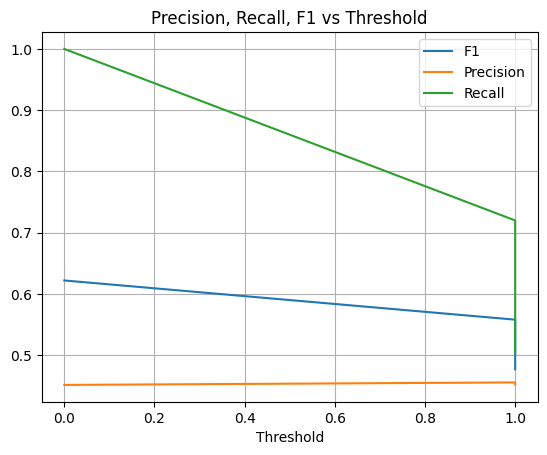

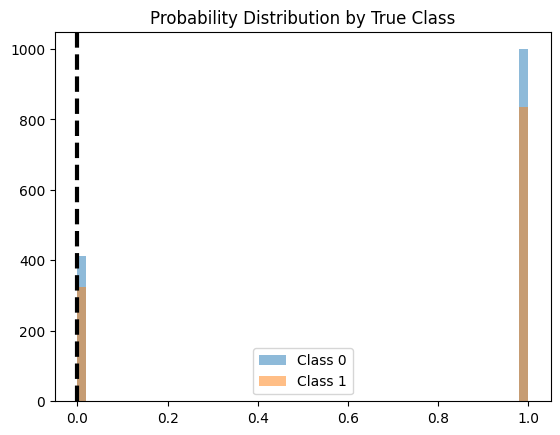

In [398]:
testing(test_result=y_train_1, test_set=X_train_1, tuned_model=tuned_model)

Best threshold: 0.00, F1 score: 0.5806


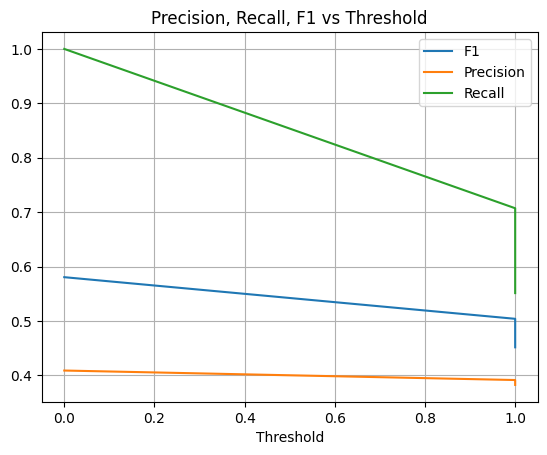

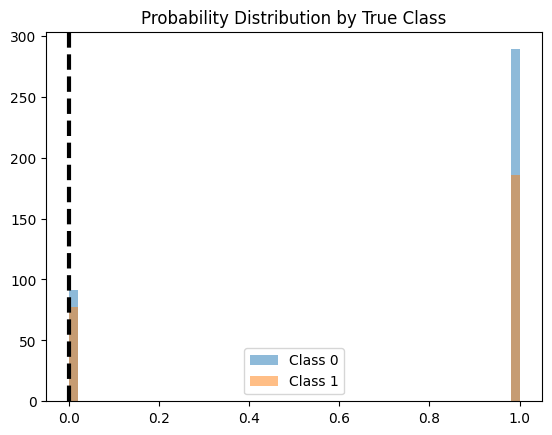

In [399]:
testing(test_result=y_test_1, test_set=X_test_1, tuned_model=tuned_model)

## Test

The Best Threshold: 0.3349581022954154


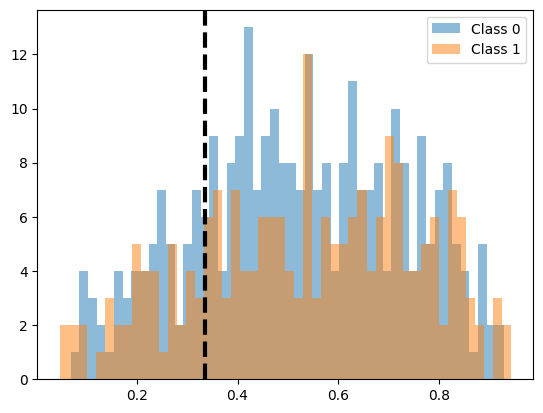

Fold 1
Train: (array([0., 1.]), array([1109,  947]))
Test: (array([0., 1.]), array([301, 213]))
Prediction: (array([0., 1.]), array([106, 408])), F1: 0.54, Accurancy: 0.4494163424124514



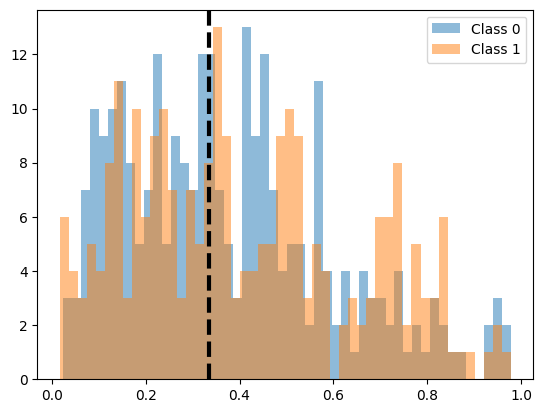

Fold 2
Train: (array([0., 1.]), array([1139,  912]))
Test: (array([0., 1.]), array([266, 248]))
Prediction: (array([0., 1.]), array([233, 281])), F1: 0.54, Accurancy: 0.5233463035019456



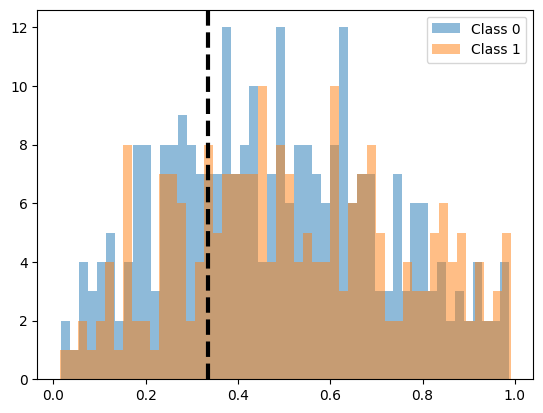

Fold 3
Train: (array([0., 1.]), array([1120,  931]))
Test: (array([0., 1.]), array([287, 227]))
Prediction: (array([0., 1.]), array([140, 374])), F1: 0.58, Accurancy: 0.5038910505836576



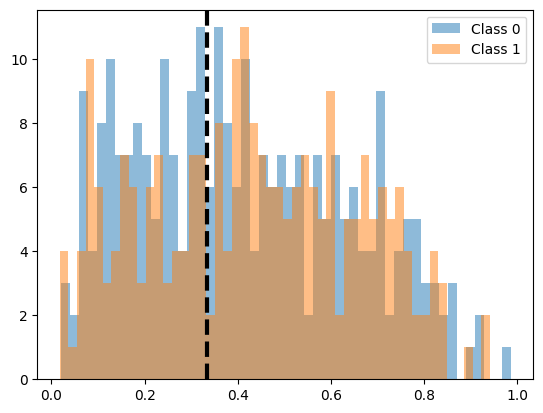

Fold 4
Train: (array([0., 1.]), array([1137,  914]))
Test: (array([0., 1.]), array([269, 245]))
Prediction: (array([0., 1.]), array([198, 316])), F1: 0.57, Accurancy: 0.5272373540856031



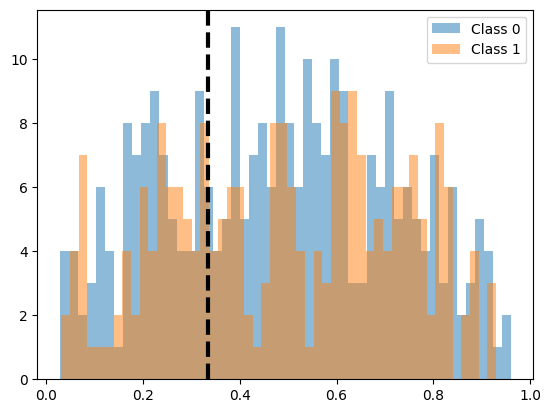

Fold 5
Train: (array([0., 1.]), array([1121,  930]))
Test: (array([0., 1.]), array([287, 227]))
Prediction: (array([0., 1.]), array([157, 357])), F1: 0.53, Accurancy: 0.4708171206225681



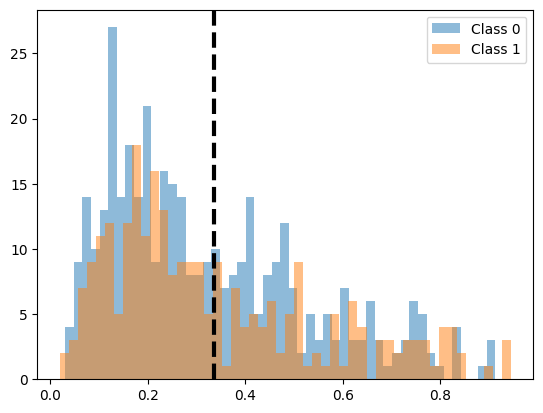


Train: (array([0., 1.]), array([1411, 1160]))
Test: (array([0., 1.]), array([380, 263]))
Prediction: (array([0., 1.]), array([383, 260]))
643 643

F1: train_cv-0.5515888135000016 test-0.3977055449330784
Accurancy: train_cv-0.49494163424124515 test-0.5101088646967341
              precision    recall  f1-score   support

         0.0       0.58      0.59      0.59       380
         1.0       0.40      0.40      0.40       263

    accuracy                           0.51       643
   macro avg       0.49      0.49      0.49       643
weighted avg       0.51      0.51      0.51       643



In [400]:
Evaluation_for_Testing_part(model=base_model, threshold=best_threshold)

# Trained-Model Saving:

In [401]:
import joblib

# Save model and threshold together
package = {
    'model': tuned_model,
    'threshold': best_threshold,
    'feature set': selected_feature_set,
}

#joblib.dump(package, '/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/xgb_model_with_threshold.pkl')
joblib.dump(package, '/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/xgb_model_with_regimes.pkl')

['/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/xgb_model_with_regimes.pkl']

# tuning model by regimes:

In [418]:
def evaluation_for_tuning_per_regimes(model, X, y, target_regime=None):
    X_train_1 = X.copy()
    y_train_1 = y.copy()
    
    '''
    res = msm_model.fit(disp=False, maxiter=500)
    proba = res.smoothed_marginal_probabilities
    proba = np.asarray(proba) if isinstance(proba, list) else proba  # guard for older versions
    regimes = proba.idxmax(axis=1).astype(int)
    '''

    f1_array_macro = []
    for fold_idx, (train_idx, test_idx) in enumerate(purged_kfold_split(X_train_1.copy())):
        X_train, X_test = X_train_1.iloc[train_idx], X_train_1.iloc[test_idx]
        y_train, y_test = y_train_1.iloc[train_idx], y_train_1.iloc[test_idx]
        
        X_train = Ensemble_Feature_Selection(model=model, X=X_train.copy(), y=y_train)
        X_test = X_test.loc[:, X_train.columns.tolist()]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
            
        f1_array_macro.append(f1_score(y_true=y_test, y_pred=y_pred))
    
    return np.mean(f1_array_macro)

def new_xgb_cv(n_estimators, max_depth, learning_rate, subsample, colsample_bytree, gamma, min_child_weight):
    
    model = XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',                  # Use 'auc' if you're optimizing AUC
        n_estimators=int(n_estimators),         # Ensure integer casting
        max_depth=int(max_depth),
        learning_rate=float(learning_rate),
        subsample=float(subsample),
        colsample_bytree=float(colsample_bytree),
        gamma=float(gamma),
        min_child_weight=int(min_child_weight),
        #objective='binary:logistic',            # Good for probability output
        #random_state=42,
        n_jobs=-1,
    )

    return evaluation_for_tuning_per_regimes(model, X_train_1, y_train_1, regime)


gmm_model.fit(X[[gmm_array]].copy())
train_regime = gmm_model.predict(X[[gmm_array]].copy())
test_regime = gmm_model.predict(Valid_set[[gmm_array]].copy())

model_per_regimes = {}
for regime in np.unique(train_regime):
    
    X_train_1 = X.loc[ train_regime == regime, :].copy()
    y_train_1 = y.loc[ train_regime == regime, :].copy()
    
    xgb_bo = BayesianOptimization(
        f=new_xgb_cv,
            pbounds = {
                'n_estimators': (1, 1000),              # around 100
                'max_depth': (1, 50),                    # around 6
                'learning_rate': (0, 50),            # around 0.3
                'subsample': (0, 1),                # around 1.0
                'colsample_bytree': (0, 1),         # around 1.0
                'gamma': (0, 10),                        # around 0
                'min_child_weight': (0, 50),             # around 1
            },
        random_state=42,
        verbose=2
    )
    
    xgb_bo.maximize(init_points=10, n_iter=10)
    xgb_params = xgb_bo.max['params']
    
    xgb_params['n_estimators'] = int(xgb_params['n_estimators'])
    xgb_params['max_depth'] = int(xgb_params['max_depth'])
    xgb_params['min_child_weight'] = int(xgb_params['min_child_weight'])

    model_per_regimes[f"Regime {regime}"] = XGBClassifier(
            use_label_encoder=False,
            eval_metric='logloss',
            n_jobs=-1,
            **xgb_params
    )

|   iter    |  target   | colsam... |   gamma   | learni... | max_depth | min_ch... | n_esti... | subsample |
-------------------------------------------------------------------------------------------------------------
| 1         | 0.0       | 0.3745    | 9.507     | 36.6      | 30.33     | 7.801     | 156.8     | 0.05808   |
| 2         | 0.0       | 0.8662    | 6.011     | 35.4      | 2.009     | 48.5      | 832.6     | 0.2123    |
| 3         | 0.4401    | 0.1818    | 1.834     | 15.21     | 26.71     | 21.6      | 291.9     | 0.6119    |
| 4         | 0.2815    | 0.1395    | 2.921     | 18.32     | 23.35     | 39.26     | 200.5     | 0.5142    |
| 5         | 0.2186    | 0.5924    | 0.4645    | 30.38     | 9.356     | 3.253     | 948.9     | 0.9656    |
| 6         | 0.0       | 0.8084    | 3.046     | 4.884     | 34.53     | 22.01     | 122.9     | 0.4952    |
| 7         | 0.3903    | 0.03439   | 9.093     | 12.94     | 33.46     | 15.59     | 520.5     | 0.5467    |
| 8       

## Test after Regimes Split:

In [419]:
X_train_1 = X.copy()
y_train_1 = y.copy()

'''
res = msm_model.fit(disp=False, maxiter=500)
proba = res.smoothed_marginal_probabilities
proba = np.asarray(proba) if isinstance(proba, list) else proba  # guard for older versions
regimes = proba.idxmax(axis=1).astype(int)
'''

f1_array_macro = []
for fold_idx, (train_idx, test_idx) in enumerate(purged_kfold_split(X_train_1.copy())):
    X_train, X_test = X_train_1.iloc[train_idx], X_train_1.iloc[test_idx]
    y_train, y_test = y_train_1.iloc[train_idx], y_train_1.iloc[test_idx]
    
    X_train = Ensemble_Feature_Selection(model=base_model, X=X_train.copy(), y=y_train)
    X_test = X_test.loc[:, X_train.columns.tolist()]
    
    gmm_model.fit(X.iloc[train_idx][[gmm_array]].copy())
    train_regime = gmm_model.predict(X.iloc[train_idx][[gmm_array]].copy())
    test_regime = gmm_model.predict(X.iloc[test_idx][[gmm_array]].copy())
    
    the_final_ypred = np.zeros(len(X_test))
    for regime in np.unique(test_regime):

        X_train_res, y_train_res = X_train.loc[train_regime == regime], y_train.loc[train_regime == regime]
        X_test_res, y_test_res = X_test.loc[test_regime == regime], y_test.loc[test_regime == regime]
        
        model = model_per_regimes[f"Regime {regime}"]
               
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test_res)
        the_final_ypred[test_regime == regime] = y_pred
    
        print(f"Train: {np.unique(y_train_res, return_counts=True)}")
        print(f"Test: {np.unique(y_test_res, return_counts=True)}")
        print(f"Prediction: {np.unique(y_pred, return_counts=True)}")
        print(f"Fold {fold_idx}, Regime {regime}: F1_score--{f1_score(y_test_res, y_pred)}")
        print()
    
    score = f1_score(y_true=y_test, y_pred=the_final_ypred)
    f1_array_macro.append(score)
    
    print(f"Fold {fold_idx}: F1_score--{score}")
    print()
    print()
    

np.mean(f1_array_macro)

Train: (array([0., 1.]), array([679, 588]))
Test: (array([0., 1.]), array([183, 123]))
Prediction: (array([0]), array([306]))
Fold 0, Regime 0: F1_score--0.0

Train: (array([0., 1.]), array([282, 213]))
Test: (array([0., 1.]), array([83, 49]))
Prediction: (array([0]), array([132]))
Fold 0, Regime 1: F1_score--0.0

Train: (array([0., 1.]), array([67, 84]))
Test: (array([0., 1.]), array([21, 25]))
Prediction: (array([0, 1]), array([27, 19]))
Fold 0, Regime 2: F1_score--0.45454545454545453

Train: (array([0., 1.]), array([81, 62]))
Test: (array([0., 1.]), array([14, 16]))
Prediction: (array([0]), array([30]))
Fold 0, Regime 3: F1_score--0.0

Fold 0: F1_score--0.08620689655172414


Train: (array([0., 1.]), array([672, 553]))
Test: (array([0., 1.]), array([146, 130]))
Prediction: (array([0, 1]), array([221,  55]))
Fold 1, Regime 0: F1_score--0.2702702702702703

Train: (array([0., 1.]), array([48, 68]))
Test: (array([0., 1.]), array([17, 23]))
Prediction: (array([1]), array([40]))
Fold 1, Re

0.3920080438352646

## File Saving:

In [423]:
import joblib

# Save model and threshold together
package = model_per_regimes
package["feature set"] = selected_feature_set

joblib.dump(package, '/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/xgb_model_with_regimes_separately.pkl')

['/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/xgb_model_with_regimes_separately.pkl']